In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
survey_data = pd.read_excel(r"C:\Users\micro\Downloads\Adams Family Reunion 2028_ Questionnaire (Responses) after reopen 2.xlsx")

In [4]:
len(survey_data)

34

In [5]:
list(survey_data.columns)

['Timestamp',
 'Your name (optional) ',
 'Home Airport Code (optional) ',
 'How many people in the clan are you representing with this response, including children and yourself? Include names if desired.',
 "What's most important to you? 1=Don't Care; 5=Most Important [Common Room]",
 "What's most important to you? 1=Don't Care; 5=Most Important [Walkable Resort]",
 "What's most important to you? 1=Don't Care; 5=Most Important [Stage]",
 "What's most important to you? 1=Don't Care; 5=Most Important [Exclusively Ours]",
 "What's most important to you? 1=Don't Care; 5=Most Important [AV Setup]",
 "What's most important to you? 1=Don't Care; 5=Most Important [Banquet Area]",
 "What's most important to you? 1=Don't Care; 5=Most Important [Kitchens in Units]",
 "What's most important to you? 1=Don't Care; 5=Most Important [Catered Meals]",
 "What's most important to you? 1=Don't Care; 5=Most Important [BBQ Facilities]",
 "What's most important to you? 1=Don't Care; 5=Most Important [Picnic 

In [6]:
columns = []
multivalue_columns = {}
for column in survey_data.columns:
    if '[' in column:
        column_base = column.split('[')[0].strip()
        column_choice = column.split('[')[1].split(']')[0].strip()
        if column_base not in columns:
            columns.append(column_base)
        multivalue_columns.setdefault(column_base, []).append(column_choice)
    else:
        columns.append(column)
columns

['Timestamp',
 'Your name (optional) ',
 'Home Airport Code (optional) ',
 'How many people in the clan are you representing with this response, including children and yourself? Include names if desired.',
 "What's most important to you? 1=Don't Care; 5=Most Important",
 'Cabins or Hotel?',
 'How much does cabins/hotel matter?',
 'Secluded vs Attractions Availability',
 'How much does secluded vs attractions matter?',
 'Setting (call 3 suburban)',
 'How much does rural/suburban/city matter?',
 'What regions would you prefer?',
 'Deal-Breakers',
 'Volunteers requested!',
 'Volunteering details: What states/regions would you cover?',
 "Email address and/or phone if you're volunteering",
 "Nominations: any places you'd recommend?",
 'Further comments, concerns or questions?',
 'Ideal lodging budget/day per bedroom',
 'Maximum lodging budget/day per bedroom',
 'Preference for unit capacity?',
 'Column 75',
 "Any activities you'd really like on site?"]

In [7]:
list(multivalue_columns.keys())

["What's most important to you? 1=Don't Care; 5=Most Important",
 'What regions would you prefer?']

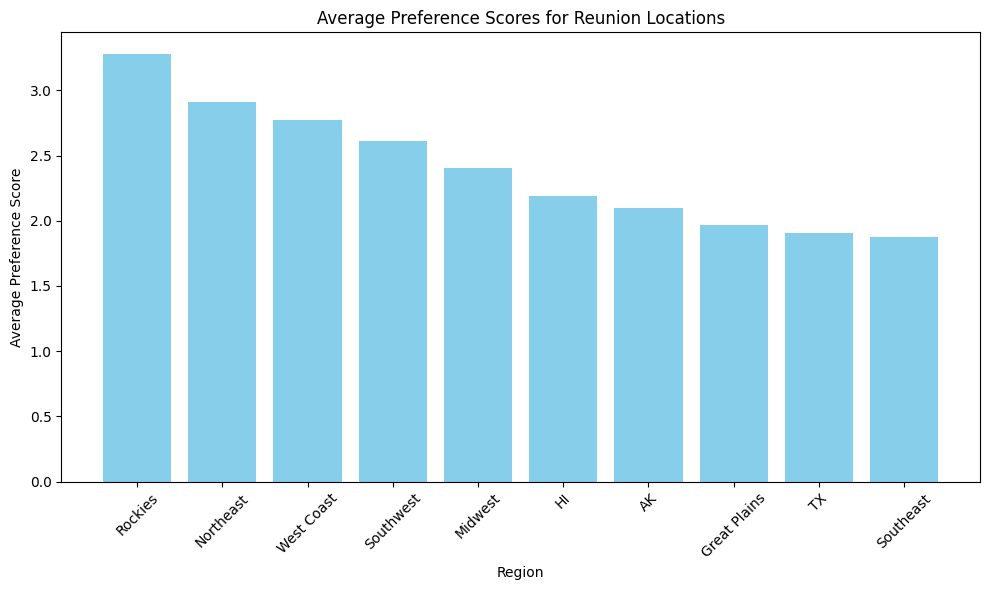

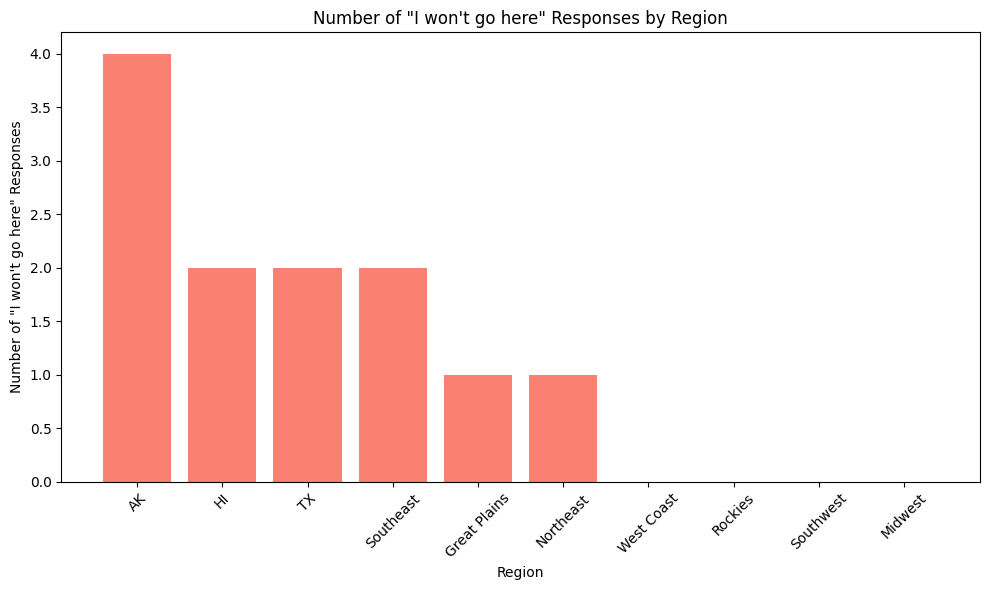

In [13]:
files_to_consider = []
possible_values = set()
for region in multivalue_columns['What regions would you prefer?']:
    original_column = f"What regions would you prefer? [{region}]"
    possible_values.update(survey_data[original_column].dropna().unique())
# {"I won't go here", 'Like it', 'Love it', 'Neutral', 'Rather not'}
value_orders = {
    "I won't go here": 0,
    'Rather not': 1,
    'Neutral': 2,
    'Like it': 3,
    'Love it': 4
}
region_scores = {}
wont_go_here_counts = {}
for region in multivalue_columns['What regions would you prefer?']:
    original_column = f"What regions would you prefer? [{region}]"
    region_scores[region] = survey_data[original_column].dropna().map(value_orders).mean()
    wont_go_here_counts[region] = (survey_data[original_column] == "I won't go here").sum()
sorted_regions = dict(sorted(region_scores.items(), key=lambda x: x[1], reverse=True))
sorted_wont_go_here = dict(sorted(wont_go_here_counts.items(), key=lambda x: x[1], reverse=True))
plt.figure(figsize=(10, 6))
plt.bar(sorted_regions.keys(), sorted_regions.values(), color='skyblue')
plt.xlabel('Region')
plt.ylabel('Average Preference Score')
plt.title('Average Preference Scores for Reunion Locations')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 6))
plt.bar(sorted_wont_go_here.keys(), sorted_wont_go_here.values(), color='salmon')
plt.xlabel('Region')
plt.ylabel('Number of "I won\'t go here" Responses')
plt.title('Number of "I won\'t go here" Responses by Region')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
df_region_scores = pd.DataFrame(list(sorted_regions.items()), columns=['Region', 'Average Preference Score'])
df_region_scores.to_csv('region_preference_scores.csv', index=False)
files_to_consider.append('region_preference_scores.csv')
df_wont_go_here = pd.DataFrame(list(sorted_wont_go_here.items()), columns=['Region', 'I won\'t go here Count'])
df_wont_go_here.to_csv('wont_go_here_counts.csv', index=False)
files_to_consider.append('wont_go_here_counts.csv')


In [15]:
# Deal breakers
deal_breaker_counts = survey_data['Deal-Breakers'].value_counts()
deal_breaker_df = pd.DataFrame(deal_breaker_counts).reset_index().rename(columns={'index': 'Deal Breaker', 'Deal-Breakers': 'Count'})
deal_breaker_counts.sort_values(ascending=False, inplace=True)
deal_breaker_df.to_csv('deal_breaker_counts.csv', index=False)
files_to_consider.append('deal_breaker_counts.csv')

In [18]:
# Feature importance ratings (1-5 scale)
importance_col = "What's most important to you? 1=Don't Care; 5=Most Important"
features = multivalue_columns[importance_col]
clan_col = 'How many people in the clan are you representing with this response, including children and yourself? Include names if desired.'
clan_sizes = pd.to_numeric(survey_data[clan_col], errors='coerce').fillna(1)

feature_ratings = {}
feature_ratings_weighted = {}
for feature in features:
    col = f"{importance_col} [{feature}]"
    values = pd.to_numeric(survey_data[col], errors='coerce').dropna()
    feature_ratings[feature] = values.mean()
    # Weighted by clan size
    mask = pd.to_numeric(survey_data[col], errors='coerce').notna()
    weighted = (pd.to_numeric(survey_data[col], errors='coerce')[mask] * clan_sizes[mask]).sum() / clan_sizes[mask].sum()
    feature_ratings_weighted[feature] = weighted

df_importance = pd.DataFrame(sorted(feature_ratings.items(), key=lambda x: x[1], reverse=True),
                             columns=['Feature', 'Average Importance'])
df_importance.to_csv('average_importance_ratings.csv', index=False)
files_to_consider.append('average_importance_ratings.csv')

df_importance_weighted = pd.DataFrame(sorted(feature_ratings_weighted.items(), key=lambda x: x[1], reverse=True),
                                      columns=['Feature', 'Weighted Importance'])
df_importance_weighted.to_csv('average_importance_ratings_weighted.csv', index=False)
files_to_consider.append('average_importance_ratings_weighted.csv')
print(f"Feature importance: {len(features)} features analyzed")
print(df_importance.head(10).to_string(index=False))

Feature importance: 51 features analyzed
           Feature  Average Importance
 Kitchens in Units            4.303030
   Walkable Resort            4.156250
     Cell Coverage            4.117647
     Reliable Wifi            4.060606
       Common Room            4.000000
               A/C            4.000000
Near Grocery Store            3.676471
       Picnic Area            3.454545
      Banquet Area            3.441176
  1 Plane Transfer            3.419355


C:\Users\micro\AppData\Local\Temp\ipykernel_36440\647797235.py:15: RuntimeWarning: invalid value encountered in scalar divide
  weighted = (pd.to_numeric(survey_data[col], errors='coerce')[mask] * clan_sizes[mask]).sum() / clan_sizes[mask].sum()


In [19]:
# Lodging type preferences
lodging_type_counts = survey_data['Cabins or Hotel?'].value_counts()
lodging_type_importance = survey_data['How much does cabins/hotel matter?'].value_counts()

df_lodging_type = pd.DataFrame({
    'Lodging Type': lodging_type_counts.index,
    'Count': lodging_type_counts.values
})
df_lodging_type.to_csv('lodging_type_preferences.csv', index=False)
files_to_consider.append('lodging_type_preferences.csv')

df_lodging_importance = pd.DataFrame({
    'Importance Level': lodging_type_importance.index,
    'Count': lodging_type_importance.values
})
df_lodging_importance.to_csv('lodging_type_importance.csv', index=False)
files_to_consider.append('lodging_type_importance.csv')
print("Lodging type preferences:")
print(df_lodging_type.to_string(index=False))
print("\nHow much does it matter:")
print(df_lodging_importance.to_string(index=False))

Lodging type preferences:
                                                                                                          Lodging Type  Count
                                                                                   Cabins, Hybrid Cabins + Condos Area     14
                                                                                           Hybrid Cabins + Condos Area      8
                                                                            Cabins, Hotel, Hybrid Cabins + Condos Area      6
Cabins, Hybrid Cabins + Condos Area, Cabins was nicer for a bit more space to have people over, bit mixed is fine too.      1
                                  Need a mix of cabins, condos and hotel style rooms. Most important is cabins/condo's      1
                                                                                    Hotel, Hybrid Cabins + Condos Area      1
                                                                                            

In [20]:
# Secluded vs Attractions preferences
secluded_col = 'Secluded vs Attractions Availability'
secluded_importance_col = 'How much does secluded vs attractions matter?'

secluded_counts = survey_data[secluded_col].value_counts()
secluded_importance = survey_data[secluded_importance_col].value_counts()

df_secluded = pd.DataFrame({
    'Preference': secluded_counts.index,
    'Count': secluded_counts.values
})
df_secluded.to_csv('secluded_vs_attractions.csv', index=False)
files_to_consider.append('secluded_vs_attractions.csv')

df_secluded_imp = pd.DataFrame({
    'Importance Level': secluded_importance.index,
    'Count': secluded_importance.values
})
df_secluded_imp.to_csv('secluded_vs_attractions_importance.csv', index=False)
files_to_consider.append('secluded_vs_attractions_importance.csv')
print("Secluded vs Attractions:")
print(df_secluded.to_string(index=False))
print("\nHow much does it matter:")
print(df_secluded_imp.to_string(index=False))

Secluded vs Attractions:
                                                         Preference  Count
                                                Lots of Attractions     11
                                                           Secluded     10
If "secluded" means "more face time w/family", then secluded it is.      1
                        I'd be happy with either, or a happy medium      1
  Some attractions within a short drive, otherwise secluded is nice      1
                                                 (Hershey has) Both      1
              Nice balance of both, otherwise lean toward secluded       1
                                              Maybe a happy medium?      1
                                                         don't care      1
                                                               Both      1

How much does it matter:
 Importance Level  Count
              3.0     10
              4.0      8
              1.0      7
              2.0      6

In [21]:
# Setting preferences (rural/suburban/city)
setting_col = 'Setting (call 3 suburban)'
setting_importance_col = 'How much does rural/suburban/city matter?'

setting_counts = survey_data[setting_col].value_counts().sort_index()
setting_importance = survey_data[setting_importance_col].value_counts()

df_setting = pd.DataFrame({
    'Setting (1=Rural, 5=City)': setting_counts.index,
    'Count': setting_counts.values
})
df_setting.to_csv('setting_preferences.csv', index=False)
files_to_consider.append('setting_preferences.csv')

df_setting_imp = pd.DataFrame({
    'Importance Level': setting_importance.index,
    'Count': setting_importance.values
})
df_setting_imp.to_csv('setting_importance.csv', index=False)
files_to_consider.append('setting_importance.csv')
print("Setting preferences (1=Rural, 3=Suburban, 5=City):")
print(df_setting.to_string(index=False))
print("\nHow much does it matter:")
print(df_setting_imp.to_string(index=False))

Setting preferences (1=Rural, 3=Suburban, 5=City):
 Setting (1=Rural, 5=City)  Count
                       1.0      5
                       2.0     13
                       3.0     12
                       4.0      3

How much does it matter:
 Importance Level  Count
              3.0     11
              4.0     10
              1.0     10
              2.0      2


In [22]:
# Lodging budget analysis
ideal_budget_col = 'Ideal lodging budget/day per bedroom'
max_budget_col = 'Maximum lodging budget/day per bedroom'

ideal_budgets = pd.to_numeric(survey_data[ideal_budget_col], errors='coerce').dropna()
max_budgets = pd.to_numeric(survey_data[max_budget_col], errors='coerce').dropna()

budget_summary = pd.DataFrame({
    'Statistic': ['count', 'mean', 'median', 'std', 'min', '25%', '75%', 'max'],
    'Ideal Budget': [ideal_budgets.count(), ideal_budgets.mean(), ideal_budgets.median(),
                     ideal_budgets.std(), ideal_budgets.min(), ideal_budgets.quantile(0.25),
                     ideal_budgets.quantile(0.75), ideal_budgets.max()],
    'Maximum Budget': [max_budgets.count(), max_budgets.mean(), max_budgets.median(),
                       max_budgets.std(), max_budgets.min(), max_budgets.quantile(0.25),
                       max_budgets.quantile(0.75), max_budgets.max()]
})
budget_summary.to_csv('lodging_budget_summary.csv', index=False)
files_to_consider.append('lodging_budget_summary.csv')

# Individual budget responses
df_budgets = survey_data[[ideal_budget_col, max_budget_col]].dropna(how='all')
df_budgets.to_csv('lodging_budgets.csv', index=False)
files_to_consider.append('lodging_budgets.csv')
print("Lodging Budget Summary:")
print(budget_summary.to_string(index=False))

Lodging Budget Summary:
Statistic  Ideal Budget  Maximum Budget
    count     13.000000       14.000000
     mean    213.461538      307.142857
   median    200.000000      275.000000
      std     92.767285      123.813046
      min     75.000000      150.000000
      25%    150.000000      212.500000
      75%    250.000000      387.500000
      max    400.000000      550.000000


In [23]:
# Unit capacity preferences
unit_cap_col = 'Preference for unit capacity?'
unit_cap_counts = survey_data[unit_cap_col].dropna().value_counts()

df_unit_cap = pd.DataFrame({
    'Unit Capacity Preference': unit_cap_counts.index,
    'Count': unit_cap_counts.values
})
df_unit_cap.to_csv('unit_capacity_preferences.csv', index=False)
files_to_consider.append('unit_capacity_preferences.csv')
print("Unit Capacity Preferences:")
print(df_unit_cap.to_string(index=False))

Unit Capacity Preferences:
                                                                                       Unit Capacity Preference  Count
                                                                                                            2-4      2
                                                                                                              4      2
                                                                                                             4+      2
                                                                                                      2 bedroom      1
                                                                                                          2 - 4      1
                                                                                                            3-6      1
                                                                                                 1 or 2 bedroom      1
                     

In [24]:
# Home airports (for travel feasibility analysis)
airport_col = 'Home Airport Code (optional) '
airports = survey_data[airport_col].dropna()
airports = airports[airports.str.strip() != '']

df_airports = pd.DataFrame({'Home Airport': airports.values})
df_airports.to_csv('home_airports.csv', index=False)
files_to_consider.append('home_airports.csv')
print(f"Home airports collected: {len(df_airports)}")
print(df_airports.to_string(index=False))

Home airports collected: 31
Home Airport
         STL
         CVG
         PDX
         OMA
        KLVK
         PHL
         DFW
         MCI
         WAS
         STL
         DFW
         HNL
         MCI
         BOS
         MCI
         PDX
         MCI
         Cvg
         CVG
         FAT
  BUR or LAX
         JFK
         DFW
         CVG
         SMF
         OPO
         PDX
         PHX
         MCI
         MCI
         DFW


In [25]:
# Nominations and desired activities
nominations_col = "Nominations: any places you'd recommend?"
activities_col = "Any activities you'd really like on site?"
comments_col = "Further comments, concerns or questions?"

# Nominations
nominations = survey_data[nominations_col].dropna()
nominations = nominations[nominations.str.strip() != '']
df_nominations = pd.DataFrame({'Nomination': nominations.values})
df_nominations.to_csv('nominations.csv', index=False)
files_to_consider.append('nominations.csv')

# Desired activities
activities = survey_data[activities_col].dropna()
activities = activities[activities.str.strip() != '']
df_activities = pd.DataFrame({'Activity': activities.values})
df_activities.to_csv('desired_activities.csv', index=False)
files_to_consider.append('desired_activities.csv')

# Comments
comments = survey_data[comments_col].dropna()
comments = comments[comments.str.strip() != '']
df_comments = pd.DataFrame({'Comment': comments.values})
df_comments.to_csv('comments.csv', index=False)
files_to_consider.append('comments.csv')

print(f"Nominations: {len(df_nominations)} responses")
print(f"Desired activities: {len(df_activities)} responses")
print(f"Comments: {len(df_comments)} responses")

Nominations: 17 responses
Desired activities: 15 responses
Comments: 20 responses


In [29]:
# "Rather not" counts by region
rather_not_counts = {}
for region in multivalue_columns['What regions would you prefer?']:
    original_column = f"What regions would you prefer? [{region}]"
    rather_not_counts[region] = (survey_data[original_column] == 'Rather not').sum()
sorted_rather_not = dict(sorted(rather_not_counts.items(), key=lambda x: x[1], reverse=True))
df_rather_not = pd.DataFrame(list(sorted_rather_not.items()), columns=['Region', 'Rather Not Count'])
df_rather_not.to_csv('rather_not_counts.csv', index=False)
files_to_consider.append('rather_not_counts.csv')

# Volunteer data - role (coordinate/investigate) and where
volunteers_col = 'Volunteers requested!'
volunteer_details_col = 'Volunteering details: What states/regions would you cover?'

# Build a combined volunteer dataframe with role and coverage per respondent
volunteer_mask = survey_data[volunteers_col].notna() & (survey_data[volunteers_col].str.strip() != '')
df_vol_combined = survey_data.loc[volunteer_mask, [volunteers_col, volunteer_details_col]].copy()
df_vol_combined.columns = ['Role (Coordinate/Investigate)', 'States/Regions Covered']
df_vol_combined = df_vol_combined.reset_index(drop=True)
df_vol_combined.to_csv('volunteers_with_coverage.csv', index=False)
files_to_consider.append('volunteers_with_coverage.csv')
# Remove the old separate files from the list if present
for f in ['volunteer_responses.csv', 'volunteer_coverage_details.csv']:
    if f in files_to_consider:
        files_to_consider.remove(f)

print("Volunteers with coverage details:")
print(df_vol_combined.to_string(index=False))
print(f"\nRather Not counts:")
print(df_rather_not.to_string(index=False))

Volunteers with coverage details:
                                                                            Role (Coordinate/Investigate)                                                                                                                                                                                                                                                                                                                                                         States/Regions Covered
                                                                         I'm willing to investigate sites                                                                                                                                                                                                                                                                                                                                   IL, IA, WI, MN, Western PA, Western NY State
                    

In [27]:
# Final list of all files to consider
print(f"Total files to consider: {len(files_to_consider)}\n")
for i, f in enumerate(files_to_consider, 1):
    print(f"  {i:2d}. {f}")

Total files to consider: 21

   1. region_preference_scores.csv
   2. wont_go_here_counts.csv
   3. deal_breaker_counts.csv
   4. average_importance_ratings.csv
   5. average_importance_ratings_weighted.csv
   6. lodging_type_preferences.csv
   7. lodging_type_importance.csv
   8. secluded_vs_attractions.csv
   9. secluded_vs_attractions_importance.csv
  10. setting_preferences.csv
  11. setting_importance.csv
  12. lodging_budget_summary.csv
  13. lodging_budgets.csv
  14. unit_capacity_preferences.csv
  15. home_airports.csv
  16. nominations.csv
  17. desired_activities.csv
  18. comments.csv
  19. rather_not_counts.csv
  20. volunteer_responses.csv
  21. volunteer_coverage_details.csv


In [16]:
files_to_consider

['region_preference_scores.csv',
 'wont_go_here_counts.csv',
 'deal_breaker_counts.csv']

In [17]:
print("Columns:"); print(columns)
print("\nMultivalue columns:"); print(multivalue_columns)
print("\nfiles_to_consider:"); print(files_to_consider)

Columns:
['Timestamp', 'Your name (optional) ', 'Home Airport Code (optional) ', 'How many people in the clan are you representing with this response, including children and yourself? Include names if desired.', "What's most important to you? 1=Don't Care; 5=Most Important", 'Cabins or Hotel?', 'How much does cabins/hotel matter?', 'Secluded vs Attractions Availability', 'How much does secluded vs attractions matter?', 'Setting (call 3 suburban)', 'How much does rural/suburban/city matter?', 'What regions would you prefer?', 'Deal-Breakers', 'Volunteers requested!', 'Volunteering details: What states/regions would you cover?', "Email address and/or phone if you're volunteering", "Nominations: any places you'd recommend?", 'Further comments, concerns or questions?', 'Ideal lodging budget/day per bedroom', 'Maximum lodging budget/day per bedroom', 'Preference for unit capacity?', 'Column 75', "Any activities you'd really like on site?"]

Multivalue columns:
{"What's most important to you

In [34]:
destinations_df = pd.read_csv('destinations.csv')
destinations_df.loc[:,['Destination', 'Property Name', 'Property Type']].to_csv('destinations_summary.csv', index=False)


In [33]:
destinations_df.head()

,Destination,Property Name,Property Type,Website,Status,Research Date,Notes,Max Guests,Sleeping Capacity,Number of Units,...,Food & Beverage Score,Nearby Town Appeal Score,Adult Appeal Score (1-10),Cell Service,WiFi Quality,Medical Facility Distance,Grocery Distance,Logistics Score (1-10),Overall Weighted Score,Final Rank
0,Poconos,Pennsylvania,Woodloch Pines Resort,Resort,NaN,Finalist Candidate,2026-05-23,Top Poconos candidate / finalist-tier family r...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Poconos,Pennsylvania,Skytop Lodge,Lodge/Resort,NaN,Candidate,2026-05-23,Large classic Poconos lodge option.,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Poconos,Pennsylvania,Kalahari Resorts & Conventions Poconos,Waterpark Resort,NaN,Candidate,2026-05-23,Large indoor waterpark/convention resort.,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Poconos,Pennsylvania,Camelback Resort,Resort,NaN,Candidate,2026-05-23,Large resort/waterpark/ski option.,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Poconos,Pennsylvania,Shawnee Inn & Golf Resort,Resort,NaN,Candidate,2026-05-23,River/golf resort considered in Poconos set.,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
